In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from nltk.corpus import stopwords
from tensorflow.keras.regularizers import l2
%matplotlib inline
import seaborn as sns
import re
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import nltk
from nltk.stem import WordNetLemmatizer
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping
from skmultilearn.problem_transform import BinaryRelevance
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit


In [64]:
import joblib
import pickle

In [10]:
!pip install iterative-stratification

In [12]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\nihar\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [13]:
pip install iterative-stratification

Note: you may need to restart the kernel to use updated packages.


In [14]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nihar\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [15]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nihar\AppData\Roaming\nltk_data...


True

In [3]:
data=pd.read_csv("youtoxic_english_1000.csv")

In [4]:
data.head()

,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\r\nDont you reckon them 'black lives matter' ...,True,True,False,False,True,False,False,False,False,False,False,False
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False,False,False
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False,False,False


In [5]:
data.head(5)

,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\r\nDont you reckon them 'black lives matter' ...,True,True,False,False,True,False,False,False,False,False,False,False
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False,False,False
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
data['IsHomophobic'].value_counts()

IsHomophobic
False    1000
Name: count, dtype: int64

In [7]:
data['IsRadicalism'].value_counts()

IsRadicalism
False    1000
Name: count, dtype: int64

In [8]:
data.drop(['CommentId','VideoId','IsHomophobic','IsRadicalism'],inplace=True,axis=1)

In [9]:
data.head(5)

,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsReligiousHate
0,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False
1,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False
2,\r\nDont you reckon them 'black lives matter' ...,True,True,False,False,True,False,False,False,False,False
3,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False
4,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False


In [10]:
data.shape

(1000, 11)

In [11]:
data.isnull().sum()

Text               0
IsToxic            0
IsAbusive          0
IsThreat           0
IsProvocative      0
IsObscene          0
IsHatespeech       0
IsRacist           0
IsNationalist      0
IsSexist           0
IsReligiousHate    0
dtype: int64

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Text             1000 non-null   object
 1   IsToxic          1000 non-null   bool  
 2   IsAbusive        1000 non-null   bool  
 3   IsThreat         1000 non-null   bool  
 4   IsProvocative    1000 non-null   bool  
 5   IsObscene        1000 non-null   bool  
 6   IsHatespeech     1000 non-null   bool  
 7   IsRacist         1000 non-null   bool  
 8   IsNationalist    1000 non-null   bool  
 9   IsSexist         1000 non-null   bool  
 10  IsReligiousHate  1000 non-null   bool  
dtypes: bool(10), object(1)
memory usage: 17.7+ KB


In [13]:
data.columns

Index(['Text', 'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative',
       'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist',
       'IsReligiousHate'],
      dtype='object')

In [14]:
le=LabelEncoder()

In [15]:
cols=['IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative',
       'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist',
       'IsReligiousHate']

In [16]:
for col in cols:
    data[col]=le.fit_transform(data[col])

In [17]:
data.head()

,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsReligiousHate
0,If only people would just take a step back and...,0,0,0,0,0,0,0,0,0,0
1,Law enforcement is not trained to shoot to app...,1,1,0,0,0,0,0,0,0,0
2,\r\nDont you reckon them 'black lives matter' ...,1,1,0,0,1,0,0,0,0,0
3,There are a very large number of people who do...,0,0,0,0,0,0,0,0,0,0
4,"The Arab dude is absolutely right, he should h...",0,0,0,0,0,0,0,0,0,0


In [18]:
data.duplicated().sum()

np.int64(2)

In [19]:
data.shape

(1000, 11)

In [20]:
for col in cols:
    count=data[col].value_counts()
    print(f"{col}:{count}")

IsToxic:IsToxic
0    538
1    462
Name: count, dtype: int64
IsAbusive:IsAbusive
0    647
1    353
Name: count, dtype: int64
IsThreat:IsThreat
0    979
1     21
Name: count, dtype: int64
IsProvocative:IsProvocative
0    839
1    161
Name: count, dtype: int64
IsObscene:IsObscene
0    900
1    100
Name: count, dtype: int64
IsHatespeech:IsHatespeech
0    862
1    138
Name: count, dtype: int64
IsRacist:IsRacist
0    875
1    125
Name: count, dtype: int64
IsNationalist:IsNationalist
0    992
1      8
Name: count, dtype: int64
IsSexist:IsSexist
0    999
1      1
Name: count, dtype: int64
IsReligiousHate:IsReligiousHate
0    988
1     12
Name: count, dtype: int64


In [21]:
counts=[]
for col in cols:
    count=(data[col] == 1).sum()
    counts.append(count)

In [22]:
counts

[np.int64(462),
 np.int64(353),
 np.int64(21),
 np.int64(161),
 np.int64(100),
 np.int64(138),
 np.int64(125),
 np.int64(8),
 np.int64(1),
 np.int64(12)]

([<matplotlib.patches.Wedge at 0x25250798980>,
 [Text(-1.0322278860827605, -0.3801389103908144, 'IsToxic'),
  Text(0.6534502895068193, -0.8848744086837715, 'IsAbusive'),
  Text(1.0961291409065628, -0.09220036038671797, 'IsThreat'),
  Text(1.0406076140183222, 0.3565610658037337, 'IsProvocative'),
  Text(0.7233033618932678, 0.9575135751903973, 'IsObscene'),
  Text(0.13693255840877405, 1.2927681441185144, 'IsHatespeech'),
  Text(-0.6622854685985463, 1.2334415097941225, 'IsRacist'),
  Text(-1.0711303775157524, 1.0500855747809137, 'IsNationalist'),
  Text(-1.1652301870835682, 1.0964664204202486, 'IsSexist'),
  Text(-1.2719636235448497, 1.127877892494864, 'IsReligiousHate')],
 [Text(-0.7976306392457694, -0.2937437034838111, '33.5%'),
  Text(0.5049388600734512, -0.6837665885283688, '25.6%'),
  Text(0.8470088816096167, -0.07124573302610024, '1.5%'),
  Text(0.8041058835596125, 0.27552445993924873, '11.7%'),
  Text(0.572615161498837, 0.7580315803590645, '7.2%'),
  Text(0.11059937409939442, 1.044

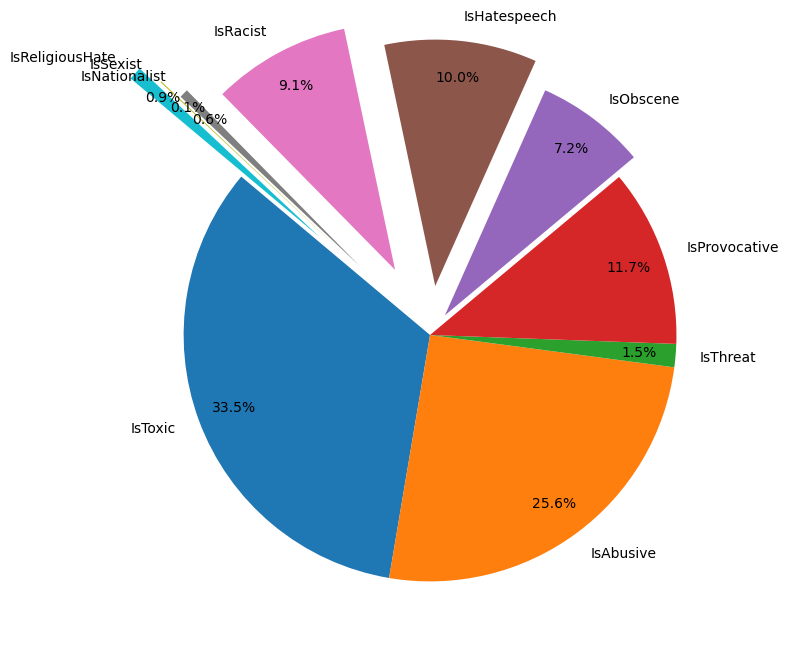

In [23]:
explode = [0, 0, 0, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
plt.figure(figsize=(10, 8))
plt.pie(
    counts,
    labels=cols,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    pctdistance=0.85
)

In [24]:
data.describe()

,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsReligiousHate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,0.462000,0.353000,0.021000,0.161000,0.10000,0.138000,0.125000,0.008000,0.001000,0.01200
std,0.498803,0.478142,0.143456,0.367715,0.30015,0.345073,0.330884,0.089129,0.031623,0.10894
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,1.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
max,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.00000


In [25]:
data.head()

,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsReligiousHate
0,If only people would just take a step back and...,0,0,0,0,0,0,0,0,0,0
1,Law enforcement is not trained to shoot to app...,1,1,0,0,0,0,0,0,0,0
2,\r\nDont you reckon them 'black lives matter' ...,1,1,0,0,1,0,0,0,0,0
3,There are a very large number of people who do...,0,0,0,0,0,0,0,0,0,0
4,"The Arab dude is absolutely right, he should h...",0,0,0,0,0,0,0,0,0,0


In [26]:
data['num_characters']=data['Text'].apply(len)

In [27]:
data['num_words']=data['Text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [28]:
data['num_sentences']=data['Text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [29]:
data.head()

,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsReligiousHate,num_characters,num_words,num_sentences
0,If only people would just take a step back and...,0,0,0,0,0,0,0,0,0,0,1558,311,11
1,Law enforcement is not trained to shoot to app...,1,1,0,0,0,0,0,0,0,0,138,28,3
2,\r\nDont you reckon them 'black lives matter' ...,1,1,0,0,1,0,0,0,0,0,421,84,4
3,There are a very large number of people who do...,0,0,0,0,0,0,0,0,0,0,582,115,5
4,"The Arab dude is absolutely right, he should h...",0,0,0,0,0,0,0,0,0,0,243,54,4


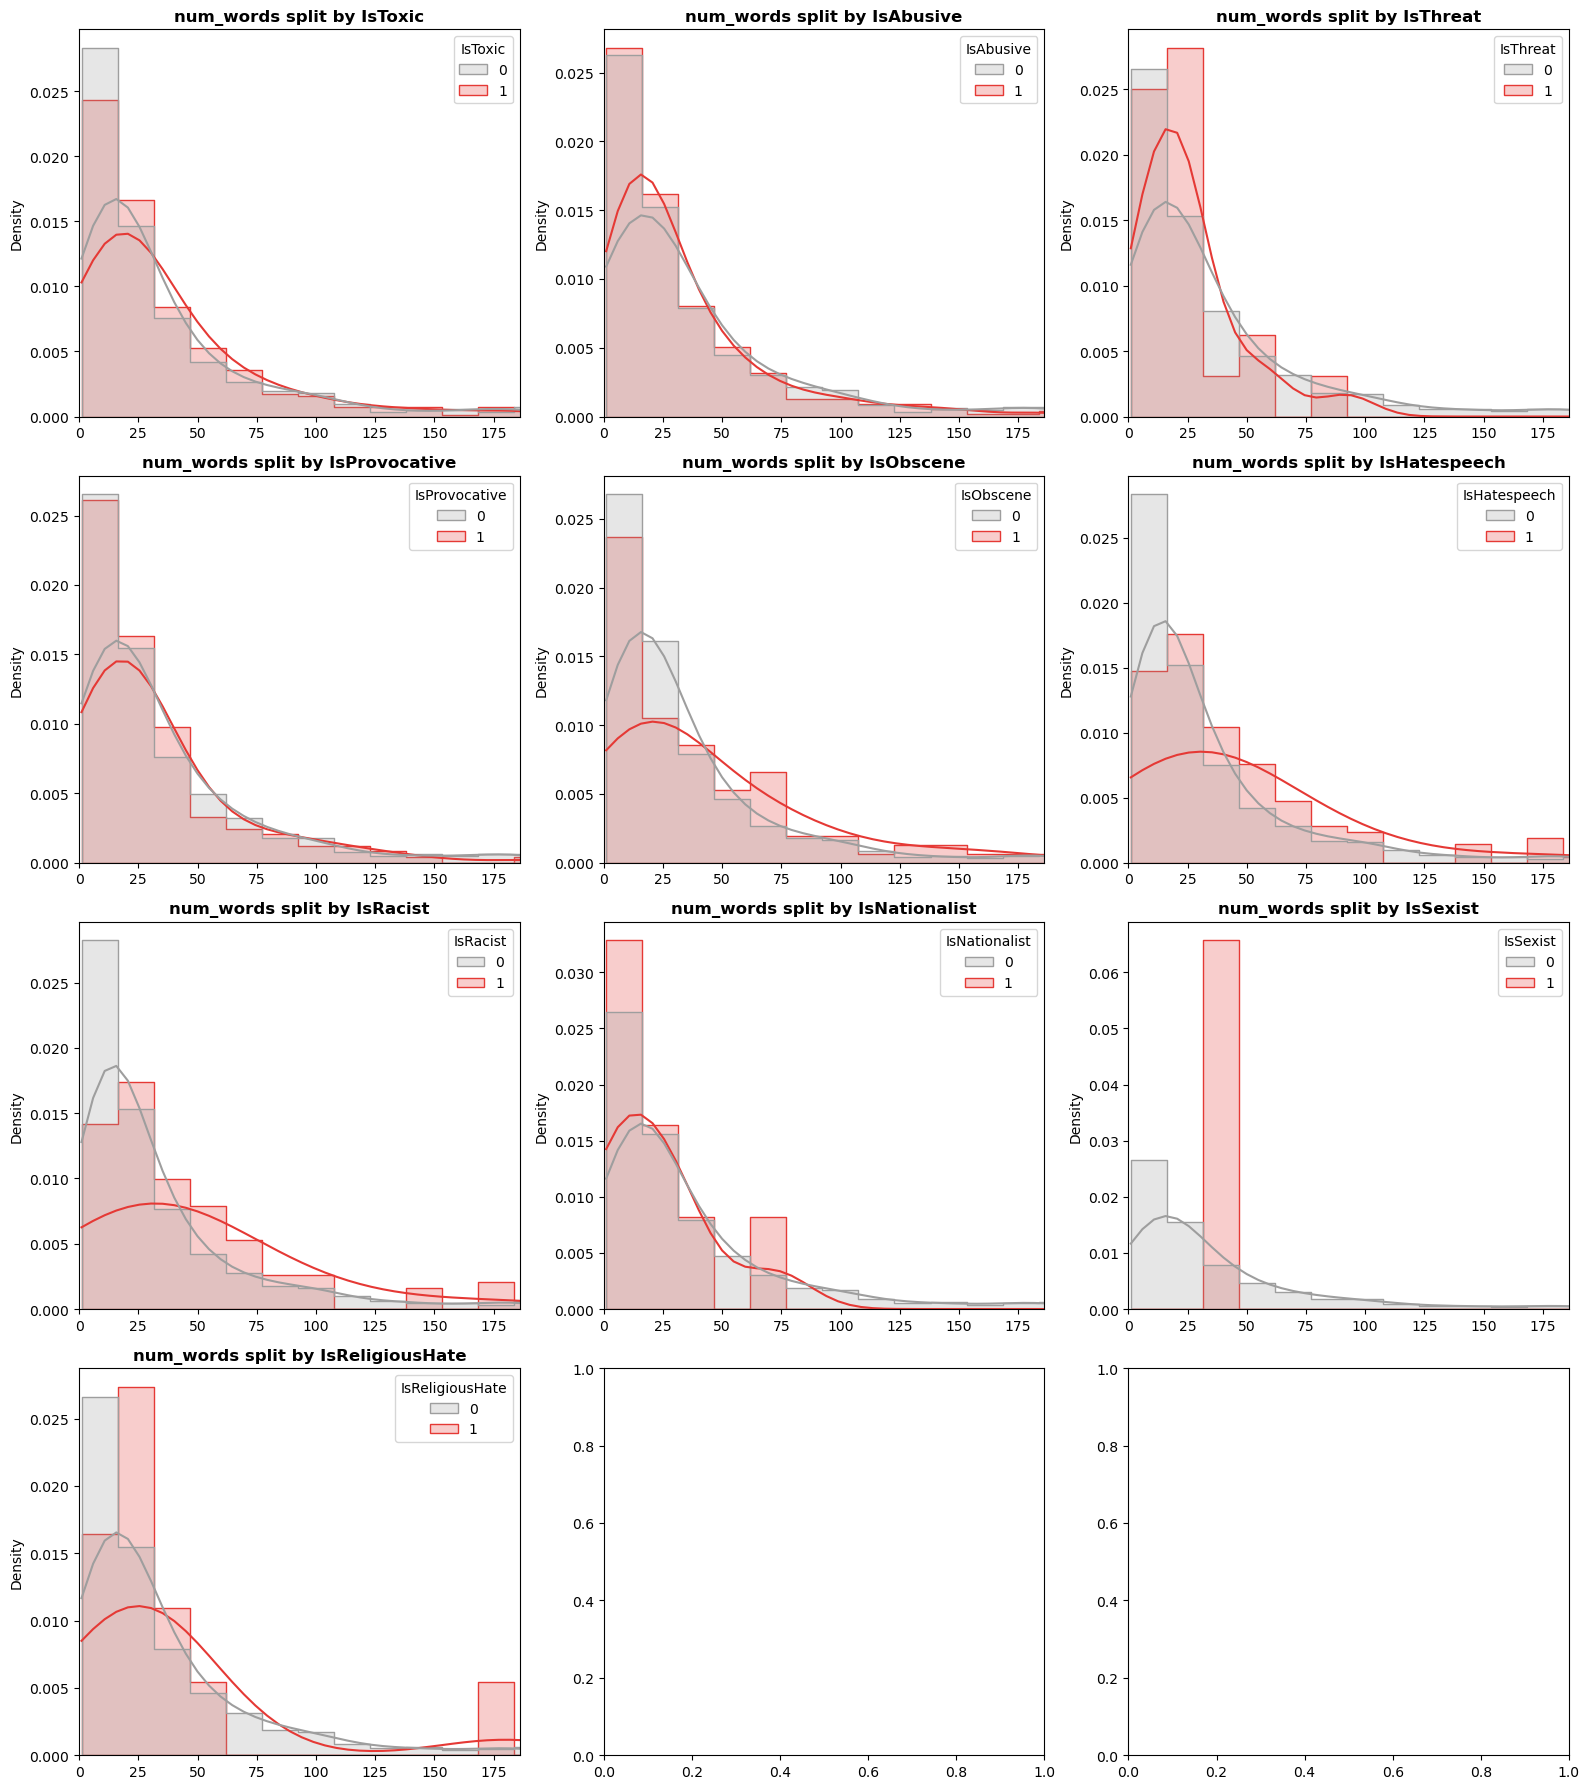

In [30]:
# 1. Define your engineered text features and target classes
text_features = ['num_characters', 'num_words', 'num_sentences']
target_cols = [
    'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene',
    'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist',
     'IsReligiousHate',
]

# 2. Pick a feature to plot (e.g., 'num_words')
# You can change this to 'num_characters' or 'num_sentences'
feature_to_plot = 'num_words'

# 3. Create a clean dynamic grid layout (4 rows x 3 columns for 12 classes)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 18))
axes = axes.flatten()  # Flatten matrix to 1D array for simple iteration

for i, target in enumerate(target_cols):
    ax = axes[i]

    # Plot distribution when target is active (1) vs inactive (0)
    sns.histplot(
        data=data,
        x=feature_to_plot,
        hue=target,
        kde=True,          # Adds a smooth trendline curve
        element="step",    # Keeps bins visually separated
        stat="density",    # Normalizes scale since class counts are unbalanced
        common_norm=False, # Normalizes each group independently for fair comparison
        palette={0: "#9E9E9E", 1: "#E53935"}, # Grey for 0, Crimson Red for 1
        ax=ax
    )

    ax.set_title(f'{feature_to_plot} split by {target}', fontsize=12, weight='bold')
    ax.set_xlabel('')  # Clear individual x-axis labels to avoid crowding
    ax.set_ylabel('Density')

    # Clip extreme long-tail text outliers so the bulk of the data is visible
    # Adjust the quantile value if your text strings are exceptionally long
    max_limit = data[feature_to_plot].quantile(0.98)
    ax.set_xlim(0, max_limit)

# 4. Clean up layout and display
plt.tight_layout()
plt.show()


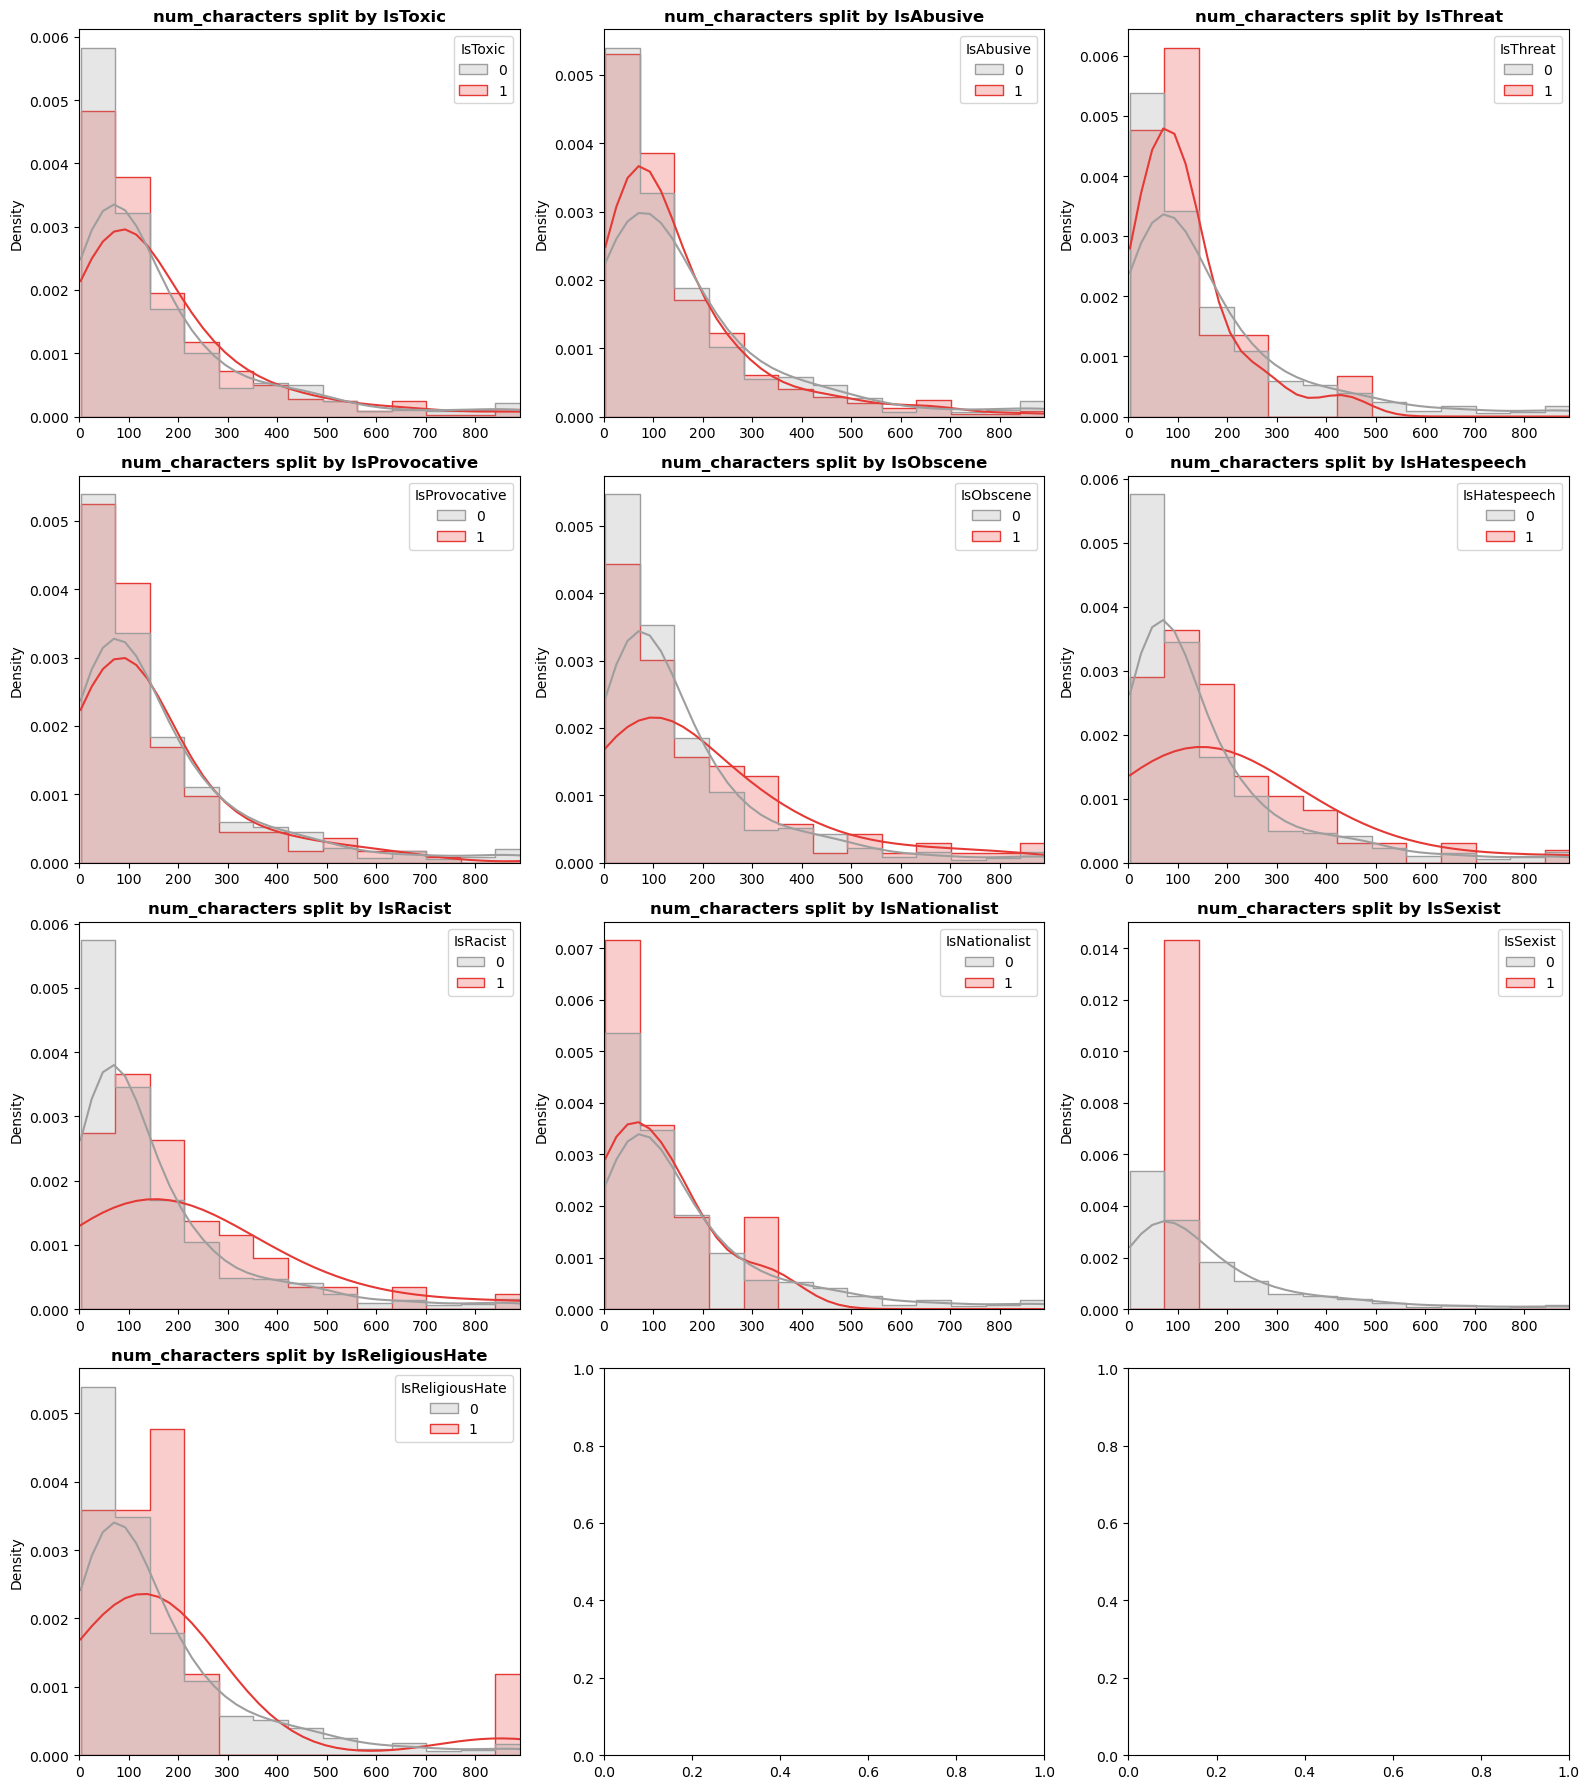

In [31]:
# 1. Define your engineered text features and target classes
text_features = ['num_characters', 'num_words', 'num_sentences']
target_cols = [
    'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene',
    'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist',
    'IsReligiousHate',
]

# 2. Pick a feature to plot (e.g., 'num_words')
# You can change this to 'num_characters' or 'num_sentences'
feature_to_plot = 'num_characters'

# 3. Create a clean dynamic grid layout (4 rows x 3 columns for 12 classes)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 18))
axes = axes.flatten()  # Flatten matrix to 1D array for simple iteration

for i, target in enumerate(target_cols):
    ax = axes[i]

    # Plot distribution when target is active (1) vs inactive (0)
    sns.histplot(
        data=data,
        x=feature_to_plot,
        hue=target,
        kde=True,          # Adds a smooth trendline curve
        element="step",    # Keeps bins visually separated
        stat="density",    # Normalizes scale since class counts are unbalanced
        common_norm=False, # Normalizes each group independently for fair comparison
        palette={0: "#9E9E9E", 1: "#E53935"}, # Grey for 0, Crimson Red for 1
        ax=ax
    )

    ax.set_title(f'{feature_to_plot} split by {target}', fontsize=12, weight='bold')
    ax.set_xlabel('')  # Clear individual x-axis labels to avoid crowding
    ax.set_ylabel('Density')

    # Clip extreme long-tail text outliers so the bulk of the data is visible
    # Adjust the quantile value if your text strings are exceptionally long
    max_limit = data[feature_to_plot].quantile(0.98)
    ax.set_xlim(0, max_limit)

# 4. Clean up layout and display
plt.tight_layout()
plt.show()


In [32]:
data['num_sentences'].value_counts()

num_sentences
1     476
2     207
3     117
4      71
5      38
6      26
7      17
8      16
10      6
9       5
12      5
11      4
13      3
16      2
15      2
19      2
17      1
55      1
14      1
Name: count, dtype: int64

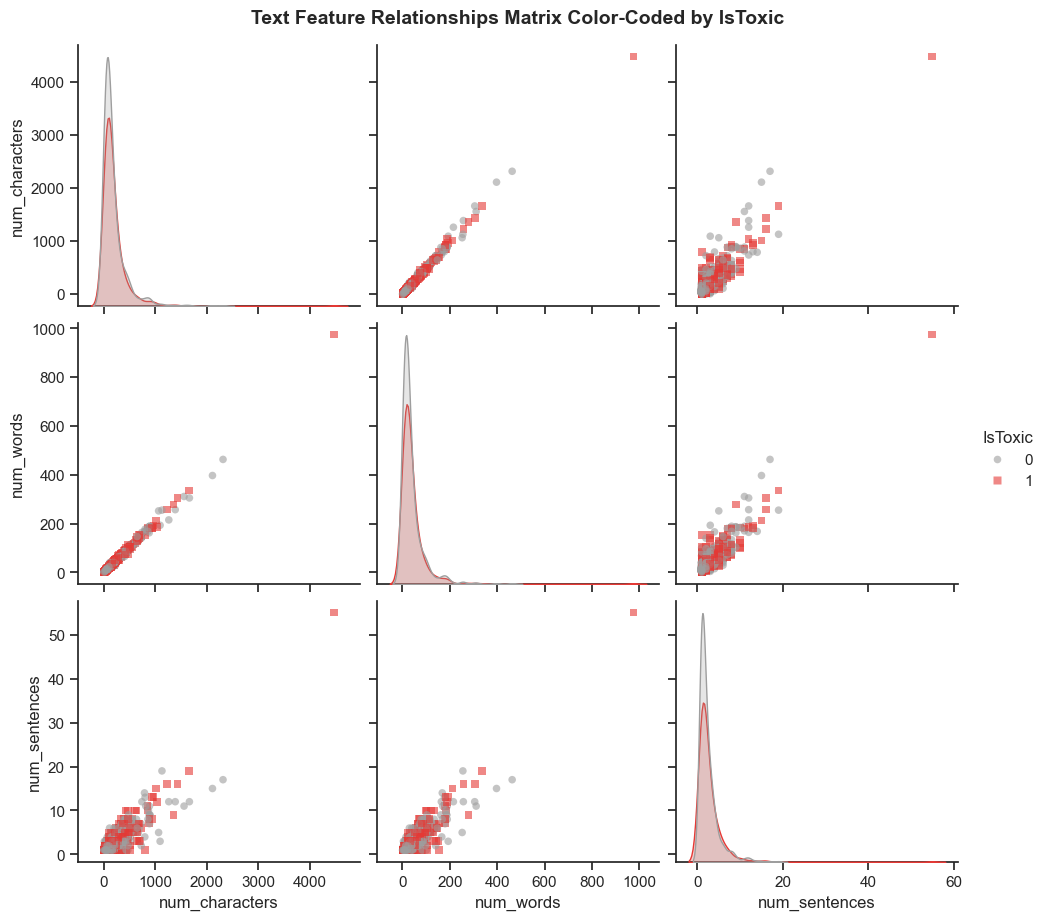

In [33]:
# 1. Define your numerical engineered features
text_features = ['num_characters', 'num_words', 'num_sentences']

# 2. Pick a primary target label to color-code your points (e.g., IsToxic)
primary_target = 'IsToxic'

# 3. Create a clean subset dataframe containing only what we need to plot
# This keeps the pairplot lightweight and fast to execute
plot_df = data[text_features + [primary_target]].copy()

# 4. Generate the high-resolution pairplot matrix
sns.set_theme(style="ticks")
g = sns.pairplot(
    data=plot_df,
    hue=primary_target,
    palette={0: "#9E9E9E", 1: "#E53935"},  # Clean Grey for 0, Crimson Red for 1
    markers=["o", "s"],                    # Circle for 0, Square for 1
    diag_kind="kde",                        # Smooth density plots on the diagonal
    plot_kws={'alpha': 0.6, 'edgecolor': 'none', 's': 30}, # Makes overlapping points transparent
    height=3.0,                             # Size of each individual subplot square
    aspect=1.1
)

# 5. Add an overall title and polish the layout
g.fig.suptitle(f"Text Feature Relationships Matrix Color-Coded by {primary_target}", y=1.02, fontsize=14, weight='bold')
plt.show()


<Axes: >

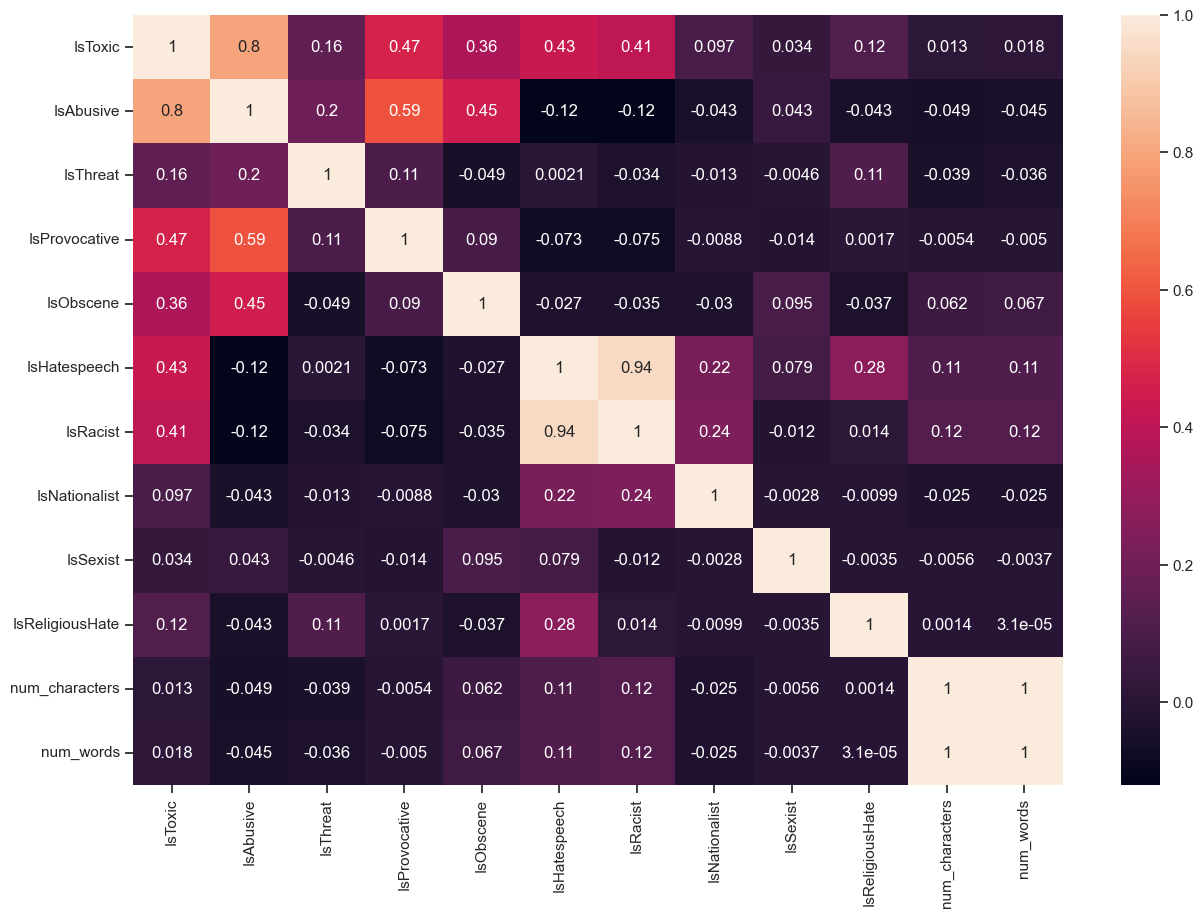

In [34]:
df=data.drop(columns=['Text','num_sentences'])
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(),annot=True)

In [35]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"what's", "what is ", text)
    text = re.sub(r"\'s", " ", text)
    text = re.sub(r"\'ve", " have ", text)
    text = re.sub(r"can't", "cannot ", text)
    text = re.sub(r"n't", " not ", text)
    text = re.sub(r"i'm", "i am ", text)
    text = re.sub(r"\'re", " are ", text)
    text = re.sub(r"\'d", " would ", text)
    text = re.sub(r"\'ll", " will ", text)
    text = re.sub(r"\'scuse", " excuse ", text)
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip(' ')
    return text

In [36]:
data['Text']=data['Text'].map(lambda x: clean_text(x))

In [37]:
data['Text'][0]

'if only people would just take a step back and not make this case about them because it was not about anyone except the two people in that situation to lump yourself into this mess and take matters into your own hands makes these kinds of protests selfish and without rational thought and investigation the guy in this video is heavily emotional and hyped up and wants to be heard and when he gets heard he just presses more and more he was never out to have a reasonable discussion kudos to the smerconish for keeping level the whole time and letting masri make himself out to be a fool how dare he and those that tore that city down in protest make this about themselves and to dishonor the entire incident with their own hate by the way since when did police brutality become an epidemic i wish everyone would just stop pretending like they were there and they knew exactly what was going on because there no measurable amount of people that honestly witnessed this incident so none of us have a 

In [38]:
STOPWORDS_SET = set(stopwords.words('english'))
def transform_text(text):
    # 1. Convert to lowercase
    text = text.lower()

    # 2. Split the string into individual words
    words = text.split()

    # 3. Keep only the words that are NOT in the stopword set
    filtered_words = [w for w in words if w not in STOPWORDS_SET]

    # 4. Join the clean words back into a single string
    return " ".join(filtered_words)

In [39]:
data['transformed_text']=data['Text'].apply(lambda x:transform_text(x))

In [40]:
data['transformed_text'][0]

'people would take step back make case anyone except two people situation lump mess take matters hands makes kinds protests selfish without rational thought investigation guy video heavily emotional hyped wants heard gets heard presses never reasonable discussion kudos smerconish keeping level whole time letting masri make fool dare tore city protest make dishonor entire incident hate way since police brutality become epidemic wish everyone would stop pretending like knew exactly going measurable amount people honestly witnessed incident none us clue way whole issue swung grand jury informed trust majority rule right course action let also thank 99 999 police officers america actually serve protect even bit jerk pull respect job know someone many people going pout held accountable actions people hate police need officer two around emergency'

In [41]:
lemmatizer = WordNetLemmatizer()

In [42]:
data['transformed_text']=data['transformed_text'].apply(lambda x:lemmatizer.lemmatize(x))

In [43]:
wc=WordCloud(width=500,height=500,min_font_size=10,background_color="white")

In [44]:
toxic_wc=wc.generate(data[data['IsToxic']==1]['transformed_text'].str.cat(sep=" "))

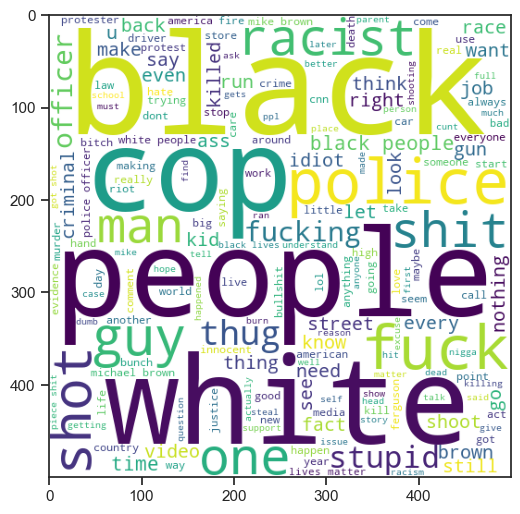

In [45]:
plt.figure(figsize=(15, 6))
plt.imshow(toxic_wc)

In [46]:
toxic_wc=wc.generate(data[data['IsThreat']==1]['transformed_text'].str.cat(sep=" "))

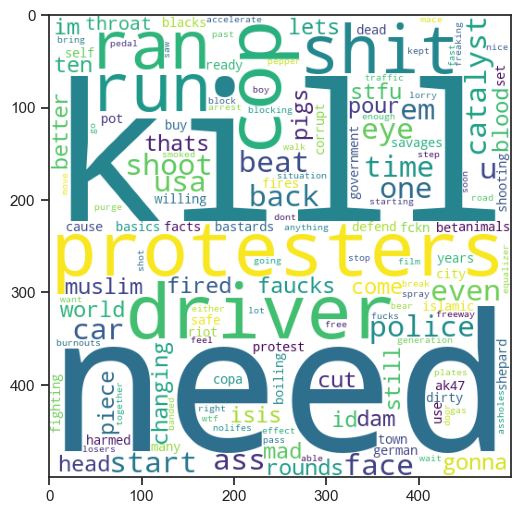

In [47]:
plt.figure(figsize=(15, 6))
plt.imshow(toxic_wc)

In [48]:
toxic_corpus=[]
for text in data[data['IsToxic']==1]['transformed_text'].tolist():
    for word in text.split():
        toxic_corpus.append(word)

In [49]:
data['transformed_text'][0]

'people would take step back make case anyone except two people situation lump mess take matters hands makes kinds protests selfish without rational thought investigation guy video heavily emotional hyped wants heard gets heard presses never reasonable discussion kudos smerconish keeping level whole time letting masri make fool dare tore city protest make dishonor entire incident hate way since police brutality become epidemic wish everyone would stop pretending like knew exactly going measurable amount people honestly witnessed incident none us clue way whole issue swung grand jury informed trust majority rule right course action let also thank 99 999 police officers america actually serve protect even bit jerk pull respect job know someone many people going pout held accountable actions people hate police need officer two around emergency'

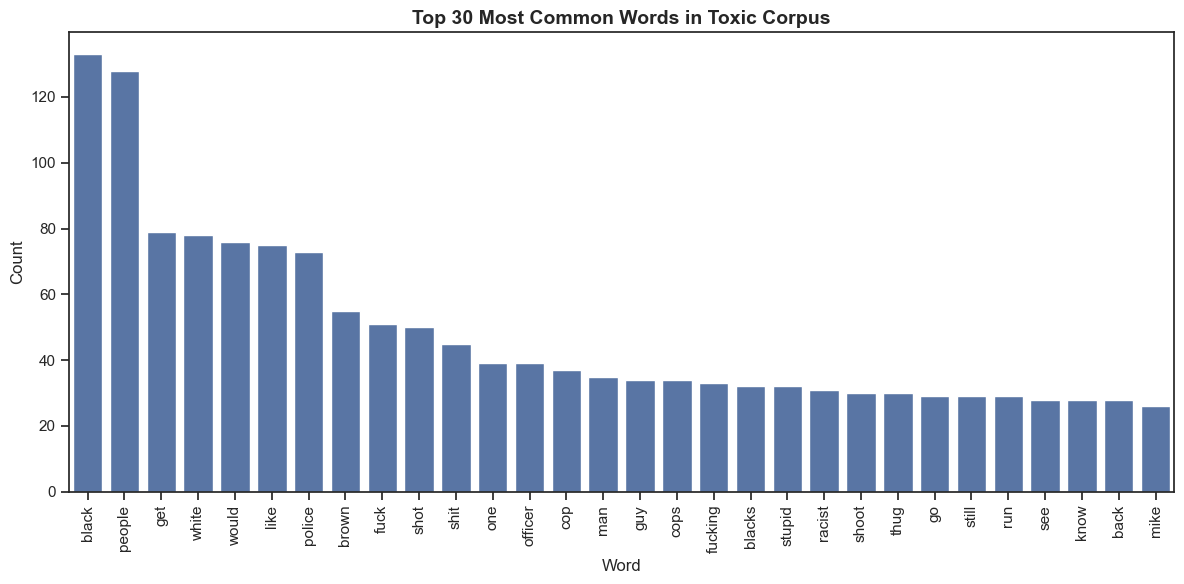

In [50]:
top_30_df = pd.DataFrame(Counter(toxic_corpus).most_common(30), columns=['Word', 'Count'])

# 2. Plot using modern named keyword arguments (x= and y=)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_30_df, x='Word', y='Count')

# 3. Rotate labels vertically for readability
plt.xticks(rotation='vertical')
plt.title("Top 30 Most Common Words in Toxic Corpus", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

In [51]:
abusive_corpus=[]
for text in data[data['IsAbusive']==1]['transformed_text'].tolist():
    for word in text.split():
        abusive_corpus.append(word)

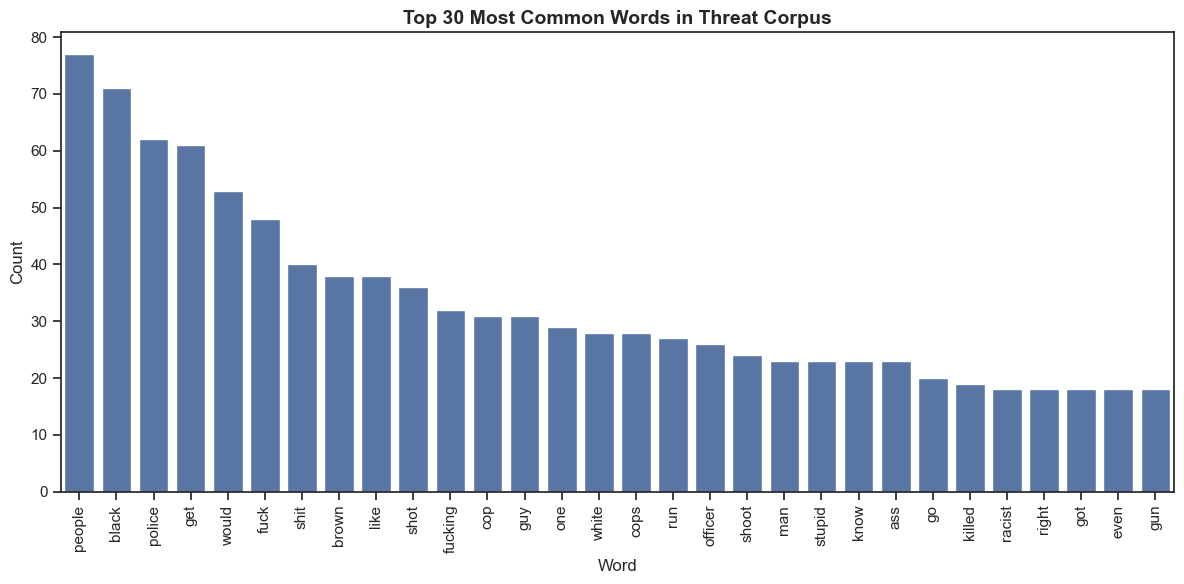

In [52]:
top_30_df = pd.DataFrame(Counter(abusive_corpus).most_common(30), columns=['Word', 'Count'])

# 2. Plot using modern named keyword arguments (x= and y=)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_30_df, x='Word', y='Count')

# 3. Rotate labels vertically for readability
plt.xticks(rotation='vertical')
plt.title("Top 30 Most Common Words in Threat Corpus", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

In [53]:
data['IsAbusive'].value_counts()

IsAbusive
0    647
1    353
Name: count, dtype: int64

In [54]:
# 1. Define X (The input text column your neural network will read)
# Use 'transformed_text' if you want the cleaned words, or 'Text' for raw text
X = data['transformed_text'].values

# 2. Define Y (Only the 12 binary target labels)
target_cols = [
    'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene',
    'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist', 'IsReligiousHate'
]
Y = data[target_cols].values


In [55]:
# Vectorize the text data using TF-IDF
vect = TfidfVectorizer(max_features=5000, stop_words='english')
X = vect.fit_transform(data['transformed_text'])
Y = data[target_cols].values

In [56]:
Y.shape

(1000, 10)

In [57]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [58]:
NUM_CLASS=Y.shape[1]
NUM_CLASS

10

In [59]:
# Calculate a weight for each of the 12 columns
# Formula: (Total Negative Labels) / (Total Positive Labels)
total_rows = len(y_train)
pos_counts = np.sum(y_train, axis=0)
neg_counts = total_rows - pos_counts

# Add a tiny value (1e-5) to prevent division by zero
pos_weights = neg_counts / (pos_counts + 1e-5)


In [60]:
model = Sequential([
    # 1. Expanded to 256 units so the model has enough capacity to handle sparse TF-IDF text features
    Dense(256, activation='relu', kernel_regularizer=l2(0.0005), input_shape=(x_train.shape[1],)),
    Dropout(0.4),

    # 2. Added a robust secondary dense layer
    Dense(128, activation='relu', kernel_regularizer=l2(0.0005)),
    Dropout(0.3),

    Dense(NUM_CLASS, activation='sigmoid')
])

C:\Users\nihar\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [61]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'binary_accuracy',
        tf.keras.metrics.F1Score(average='macro', threshold=0.5, name='macro_f1'),
        tf.keras.metrics.AUC(multi_label=True, name='auc_roc')
    ]
)

In [62]:
history = model.fit(
    x_train.toarray(),
    y_train,
    epochs=25, # Increased slightly to give the deeper network more time to adjust weights
    batch_size=32,
    validation_split=0.2
)

Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - auc_roc: 0.4387 - binary_accuracy: 0.8058 - loss: 0.8505 - macro_f1: 0.0653 - val_auc_roc: 0.4714 - val_binary_accuracy: 0.8719 - val_loss: 0.6773 - val_macro_f1: 0.0000e+00
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - auc_roc: 0.4528 - binary_accuracy: 0.8681 - loss: 0.5273 - macro_f1: 0.0099 - val_auc_roc: 0.4607 - val_binary_accuracy: 0.8719 - val_loss: 0.3984 - val_macro_f1: 0.0000e+00
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - auc_roc: 0.5252 - binary_accuracy: 0.8641 - loss: 0.3902 - macro_f1: 0.0272 - val_auc_roc: 0.4936 - val_binary_accuracy: 0.8719 - val_loss: 0.3555 - val_macro_f1: 0.0000e+00
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - auc_roc: 0.6495 - binary_accuracy: 0.8648 - loss: 0.3526 - macro_f1: 0.0316 - val_auc_roc: 0.5126 - val_binary_accuracy: 0.8719 - val_loss: 0.3438 - val_macro_f1: 0.0000e+00
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - auc_roc: 0.7354 - binary_accuracy: 0.87

In [76]:
# 1. Heavily downsized network structure to restrict memorization capacity
model = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.001), input_shape=(x_train.shape[1],)),
    Dropout(0.5),

    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),

    Dense(NUM_CLASS, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005), # Kept small learning rate for stability
    loss='binary_crossentropy',
    metrics=[
        'binary_accuracy',
        tf.keras.metrics.F1Score(average='macro', threshold=0.5, name='macro_f1'),
        tf.keras.metrics.AUC(multi_label=True, name='auc_roc')
    ]
)

# 2. Define the Early Stopping Safeguard
# It halts training if validation Macro F1 fails to improve for 4 straight epochs
early_stop = EarlyStopping(
    monitor='val_macro_f1',
    mode='max',
    patience=4,
    restore_best_weights=True, # Automatically rewinds the model to its best epoch
    verbose=1
)

# 3. Fit the network with the callback active
history = model.fit(
    x_train, # Your combined TF-IDF + metadata matrix
    y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop] # Plugs in the automated cutoff rule
)


Epoch 1/25


C:\Users\nihar\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - auc_roc: 0.4258 - binary_accuracy: 0.6722 - loss: 0.8150 - macro_f1: 0.1658 - val_auc_roc: 0.3907 - val_binary_accuracy: 0.8338 - val_loss: 0.7724 - val_macro_f1: 0.1139
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - auc_roc: 0.4682 - binary_accuracy: 0.8039 - loss: 0.7440 - macro_f1: 0.1260 - val_auc_roc: 0.3991 - val_binary_accuracy: 0.8331 - val_loss: 0.7133 - val_macro_f1: 0.1147
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - auc_roc: 0.4903 - binary_accuracy: 0.8244 - loss: 0.6887 - macro_f1: 0.1294 - val_auc_roc: 0.4415 - val_binary_accuracy: 0.8331 - val_loss: 0.6603 - val_macro_f1: 0.1147
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - auc_roc: 0.4914 - binary_accuracy: 0.8286 - loss: 0.6348 - macro_f1: 0.1145 - val_auc_roc: 0.4238 - val_binary_accuracy: 0.8331 - val_loss: 0.6007 - val_macro_f1: 0.1147
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - auc_roc: 0.4999 - binary_accuracy: 0.8398 - loss: 0.5720 - macro_f

In [176]:
# Install the multi-label stratification tool if you haven't already
# !pip install iterative-stratification

# 1. FIXED: Use a Stratified Split so all 12 classes exist in both Train and Validation sets
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, val_index in msss.split(X, Y):
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = Y[train_index], Y[val_index]

# 2. Re-initialize your Random Forest model
base_classifier = RandomForestClassifier(
    n_estimators=250,
    max_depth=15,          # Slightly increased depth to let trees capture finer details
    class_weight='balanced',
    random_state=42
)
multi_label_model = BinaryRelevance(classifier=base_classifier)
multi_label_model.fit(x_train, y_train)

# 3. Extract the raw prediction probabilities
y_val_prob = multi_label_model.predict_proba(x_test).toarray()

# 4. FIXED: Lower the classification threshold from 0.5 to 0.3 to boost Recall
y_val_pred = (y_val_prob >= 0.50).astype(int)

# 5. Evaluate with a clean fallback strategy for rare metrics
target_cols = [
    'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene',
    'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist',
    'IsReligiousHate']

# Calculate ROC-AUC dropping columns that happen to have no active validation examples
valid_auc_cols = [i for i in range(y_test.shape[1]) if len(np.unique(y_test[:, i])) > 1]
roc_auc = roc_auc_score(y_test[:, valid_auc_cols], y_val_prob[:, valid_auc_cols], average='macro')
macro_f1 = f1_score(y_test, y_val_pred, average='macro', zero_division=0)

print(f"Stratified Validation Macro F1-Score: {macro_f1:.4f}")
print(f"Stratified Validation Mean AUC-ROC:   {roc_auc:.4f}\n")

print(classification_report(y_test, y_val_pred, target_names=target_cols, zero_division=0))


Stratified Validation Macro F1-Score: 0.0677
Stratified Validation Mean AUC-ROC:   0.4532

                 precision    recall  f1-score   support

        IsToxic       0.54      0.48      0.50       107
      IsAbusive       0.26      0.13      0.17        77
       IsThreat       0.00      0.00      0.00         4
  IsProvocative       0.00      0.00      0.00        38
      IsObscene       0.00      0.00      0.00        23
   IsHatespeech       0.00      0.00      0.00        35
       IsRacist       0.00      0.00      0.00        30
  IsNationalist       0.00      0.00      0.00         3
       IsSexist       0.00      0.00      0.00         0
IsReligiousHate       0.00      0.00      0.00         4

      micro avg       0.46      0.19      0.27       321
      macro avg       0.08      0.06      0.07       321
   weighted avg       0.24      0.19      0.21       321
    samples avg       0.24      0.11      0.14       321



In [63]:
# Assume 'model' is your trained NLP pipeline object and 'tfidf' is your vectorizer
# If you are using a pipeline object, you can just save the pipeline
joblib.dump(model, 'nlp_model.keras')
joblib.dump(vect, 'vectorizer.pkl')

['vectorizer.pkl']

In [66]:
filename = 'toxic_comments_model.pkl'
pickle.dump(model, open(filename, 'wb'))

In [67]:
data['transformed_text'][0]

'people would take step back make case anyone except two people situation lump mess take matters hands makes kinds protests selfish without rational thought investigation guy video heavily emotional hyped wants heard gets heard presses never reasonable discussion kudos smerconish keeping level whole time letting masri make fool dare tore city protest make dishonor entire incident hate way since police brutality become epidemic wish everyone would stop pretending like knew exactly going measurable amount people honestly witnessed incident none us clue way whole issue swung grand jury informed trust majority rule right course action let also thank 99 999 police officers america actually serve protect even bit jerk pull respect job know someone many people going pout held accountable actions people hate police need officer two around emergency'